## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout
import warnings
warnings.filterwarnings("ignore", message="Using UFloat objects with std_dev==0*")


# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan\n")    
    global model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # DATA PLOTS
    fig, ax = plt.subplots(figsize=(10,5))
    for i, q in enumerate(g2mt.keys()):

        # FIT DATA
        # time-mask 4 fitting
        tmask = (t1_fit<g2mt[q][0])*(g2mt[q][0]<t2_fit)
        x, y, dy =  g2mt[q][0][tmask], g2mt[q][1][tmask], g2mt[q][2][tmask]

        # compute and save the fit
        fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
        g2fit.loc[i] = [q, dQ_section,
                        fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                        fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                        fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                        fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                        fit.redchi,]
        
        # PLOT FIT
        ax.errorbar(g2mt[q][0], g2mt[q][1], yerr=g2mt[q][2], fmt = 'o', c='C'+str(i), label =f'Q = {q} $\\AA^{-1}$')
        xfit = np.arange(np.min(g2mt[q][0]), np.max(g2mt[q][0]), 1e-2)
        yfit = fit.eval(t=xfit)
        ax.plot(xfit, yfit, c='C'+str(i), linestyle='--')

    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')
    ax.set_xlabel('t [s]')
    ax.set_ylabel('g2')
    ax.set_xscale('log')
    
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Qs_section[0]}:{Qs_section[-1]}-dQ={dQ_section}.txt", index=False)
    display(g2fit)

    return g2fit, fig, ax

def plotfitparams_byQ_4damaged_vGeO2(g2fit):
    print("Using Global variables: sample_name, Ndataset, Nscan \n")
    global sample_name, Ndataset, Nscan

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))

    # tau
    axs[0, 0].errorbar(g2fit.Q, g2fit.tau, yerr=g2fit.dtau, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[0, 0].set_ylabel('tau [s]')

    # beta
    axs[0, 1].errorbar(g2fit.Q, g2fit.beta, yerr=g2fit.dbeta, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[0, 1].set_ylabel('beta')

    # c
    axs[1, 0].errorbar(g2fit.Q, g2fit.c, yerr=g2fit.dc, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[1, 0].set_ylabel('c')

    # y0
    axs[1, 1].errorbar(g2fit.Q, g2fit.y0, yerr=g2fit.dy0, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[1, 1].set_ylabel('y0')

    return fig, axs

### Load masks

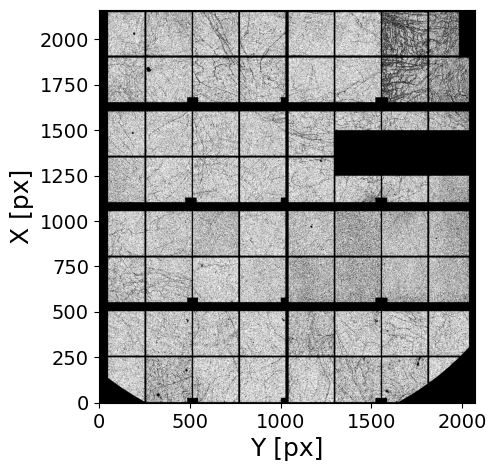

In [3]:
### e4m MASKS
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

## XPCS scan: delcoup=1.75, T=30, 75min @ 20ms ON damaged point (GeO2_6, dataset 1, scan 12)
Start of the Temperature ramp!

In [4]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =12
Nfi, Nff = 1, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=60)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 220000
Ei = 9.699998837562536
itime = 0.0201
theta = 1.7500000000000004
Q = 0.15
T = 73.70 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00013.h5 (14/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/44 loo

### Qmask

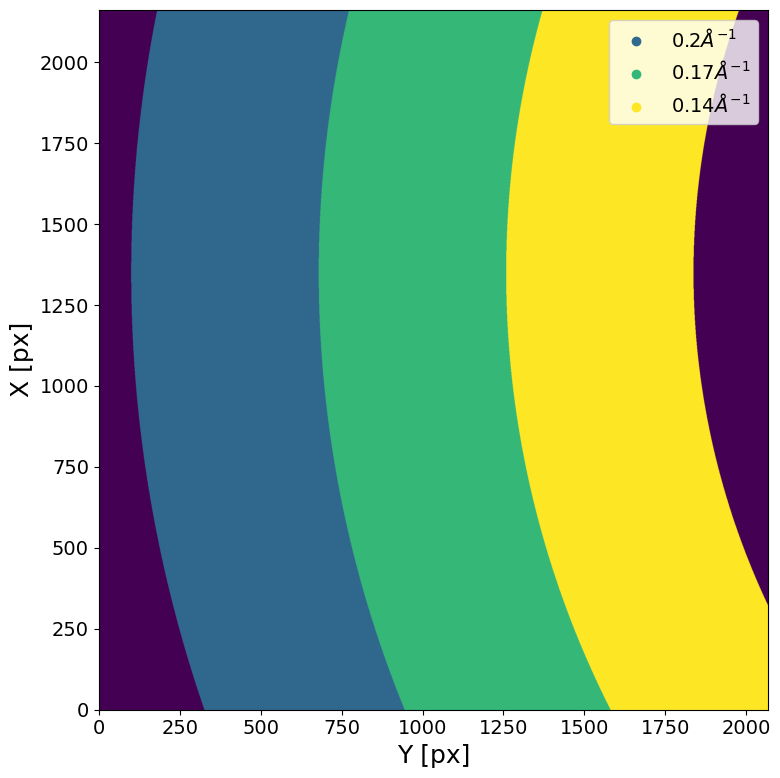

In [5]:
###################
Qs_section = [.2, .17, .14]
dQ_section = .015
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  2159 pixels (of 4471016 => 0.05 %)
################################################################################



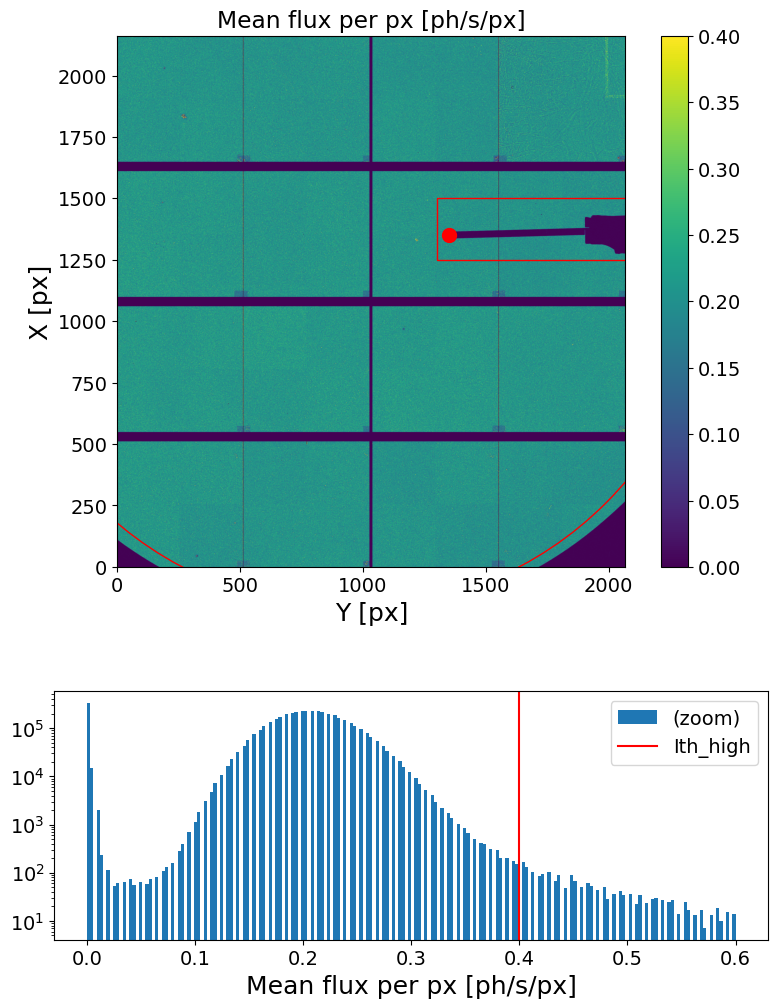

#################################################
Masked area =  93.74594052000708 %
#################################################



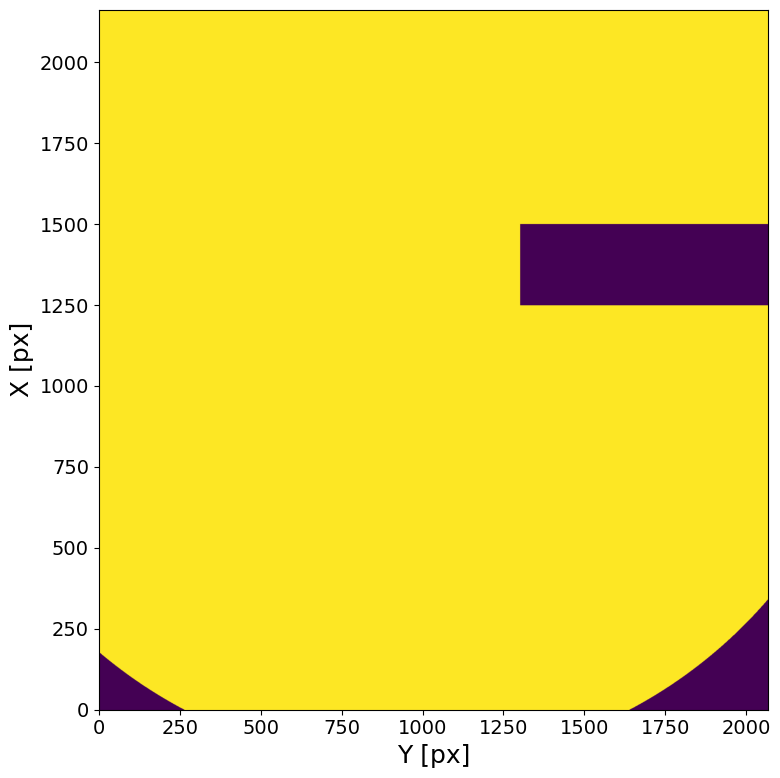

In [6]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.4, Nff=10000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [7]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

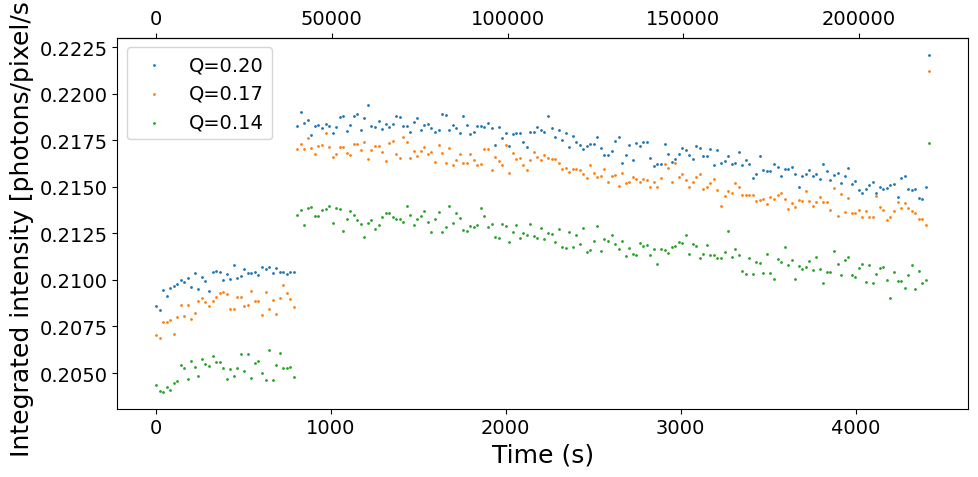

In [8]:
plt.figure(figsize=(10,5))
for q in Qmask.keys():
    plt.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
plt.legend()
plt.tight_layout(); plt.show()

### Multitau correlation of damaged-vGeO2

In [9]:
##### INPUTS #####
Nfi = 50_000
Nff = None
sparse_depth = 12
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.14:   0%|          | 0/3 [00:00<?, ?it/s]

Nff set to 217936 => (Nff-Nfi) = 41*2^sparse_depth, thrown frames = 2063 (1.21%)
Loading frames ...
Done! (elapsed time = 39.75 s)
Masking data ...
Done! (elapsed time = 114.43 s)
	 | 167936 frames X 826633 pixels
	 | sparsity = 4.35e-03
	 | memory usage (sparse.csr_array @ float32) = 6.752 GB
Computing sparse multitau G2t...


100%|██████████| 41/41 [01:29<00:00,  2.19s/it]


Done! (elapsed time = 90.1 s)
Computing dense multitau G2t...
	-> computing channels on 328 frames ...
	-> computing channels on 164 frames ...
	-> computing channels on 82 frames ...
	-> computing channels on 41 frames ...


Calculating G2tmt @ q=0.14:  33%|███▎      | 1/3 [04:13<08:27, 253.76s/it]

...

Calculating G2tmt @ q=0.14:  67%|██████▋   | 2/3 [07:25<03:37, 217.06s/it]

	-> computing channels on 20 frames ...
Done! (elapsed time = 7.28 s)
Nff set to 217936 => (Nff-Nfi) = 41*2^sparse_depth, thrown frames = 2063 (1.21%)
Loading frames ...
Done! (elapsed time = 31.9 s)
Masking data ...
Done! (elapsed time = 87.24 s)
	 | 167936 frames X 624792 pixels
	 | sparsity = 4.25e-03
	 | memory usage (sparse.csr_array @ float32) = 4.985 GB
Computing sparse multitau G2t...


100%|██████████| 41/41 [01:18<00:00,  1.92s/it]


Done! (elapsed time = 78.97 s)
Computing dense multitau G2t...
	-> computing channels on 328 frames ...
	-> computing channels on 164 frames ...
	-> computing channels on 82 frames ...
	-> computing channels on 41 frames ...
	-> computing channels on 20 frames ...
Done! (elapsed time = 9.33 s)


Calculating G2tmt @ q=0.14: 100%|██████████| 3/3 [10:52<00:00, 217.54s/it]


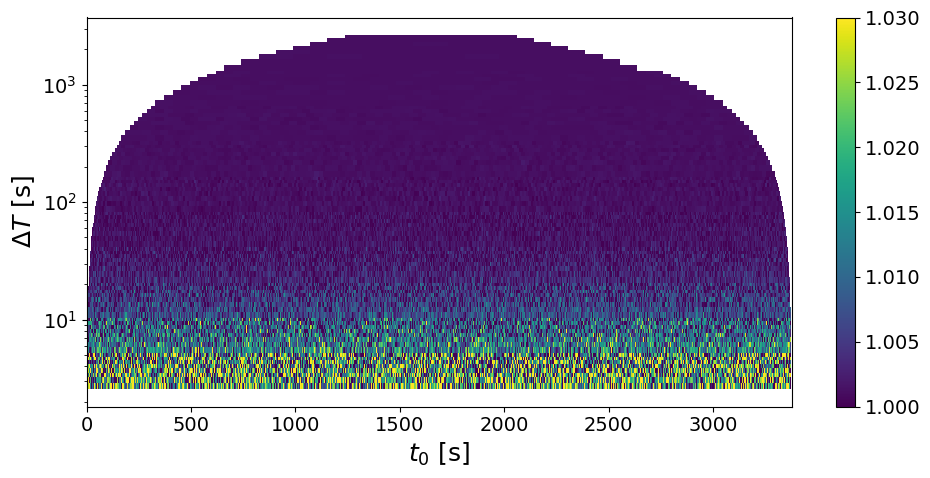

In [10]:
############################
q = .2
vmin, vmax = 1.0, 1.03
lower_corr = 4
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.20,0.015,5.129079,0.072357,1.410717,0.727307,0.007017,0.964777,0.031033,0.000246,0.791981,1.001133,0.000003,0.000315,2.266860
1,0.17,0.015,5.371626,0.092665,1.725080,0.714060,0.008178,1.145299,0.031694,0.000303,0.955297,1.001089,0.000004,0.000436,3.427906
2,0.14,0.015,5.794957,0.117614,2.029592,0.707128,0.009416,1.331638,0.032677,0.000365,1.116674,1.001237,0.000005,0.000491,3.920528


Using Global variables: sample_name, Ndataset, Nscan 



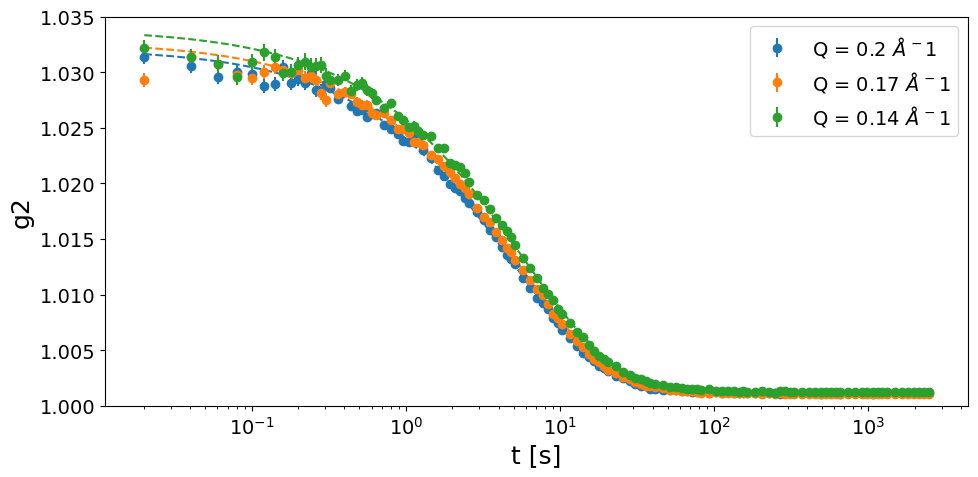

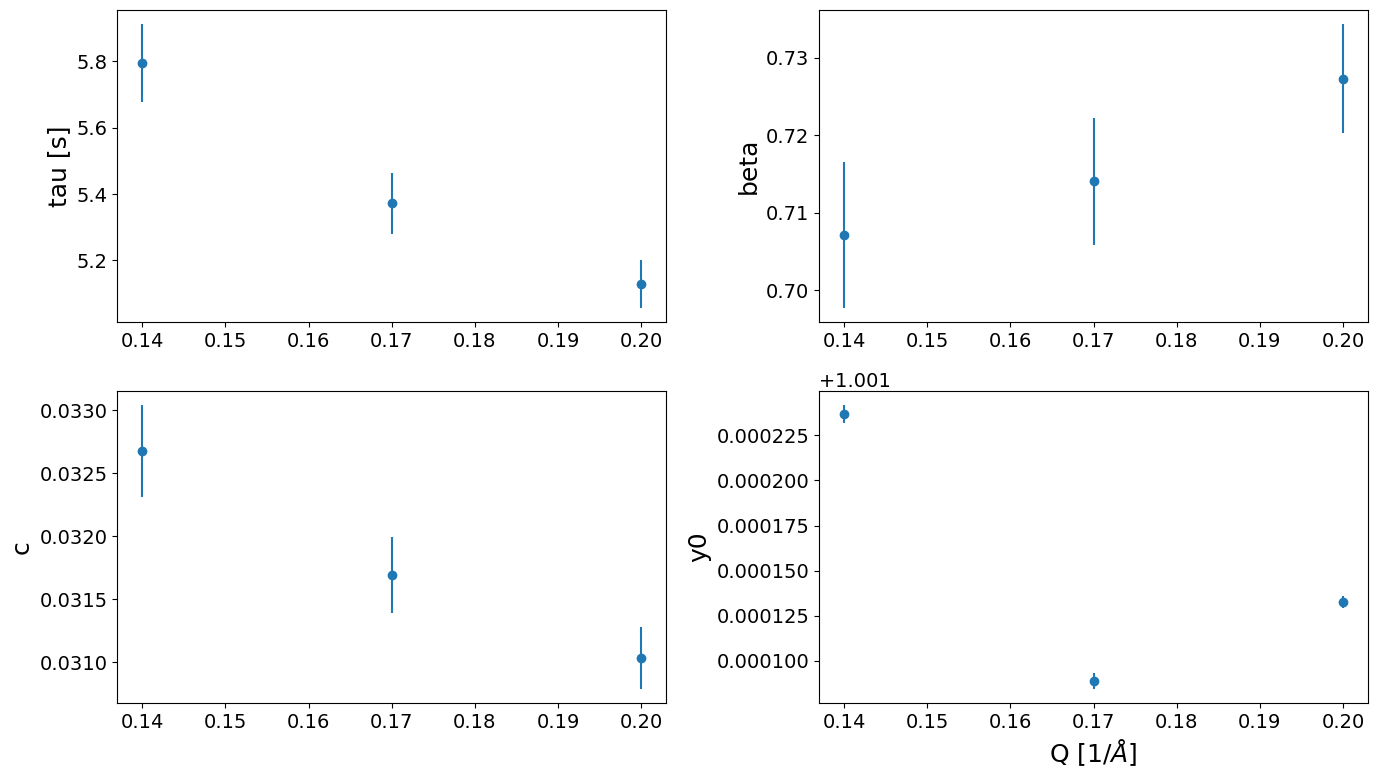

In [11]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.035)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

##   XPCS scan: delcoup = 1, T=30, 60min @ 1ms (stopped @ 2600000) (GeO2_6q_delcoup1, dataset 1, scan 2)

**ATTENZIONE!!!**
Le due strisciate in basso sul detector cambiano il tau da 5 a 1 s!!!

In [12]:
#######################################
sample_name = 'GeO2_6q_delcoup_1'
Ndataset = 1
Nscan = 2
Nfi, Nff = None, 2600000 # NO BEAM @ 2600000 frames
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 9.699998837562536
itime = 0.0011
theta = 1.0000000000000004
Q = 0.09
T = 60.76 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00019.h5 (20/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00036.h5 (37/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025.h5 (26/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/521 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_0000

### Qmask

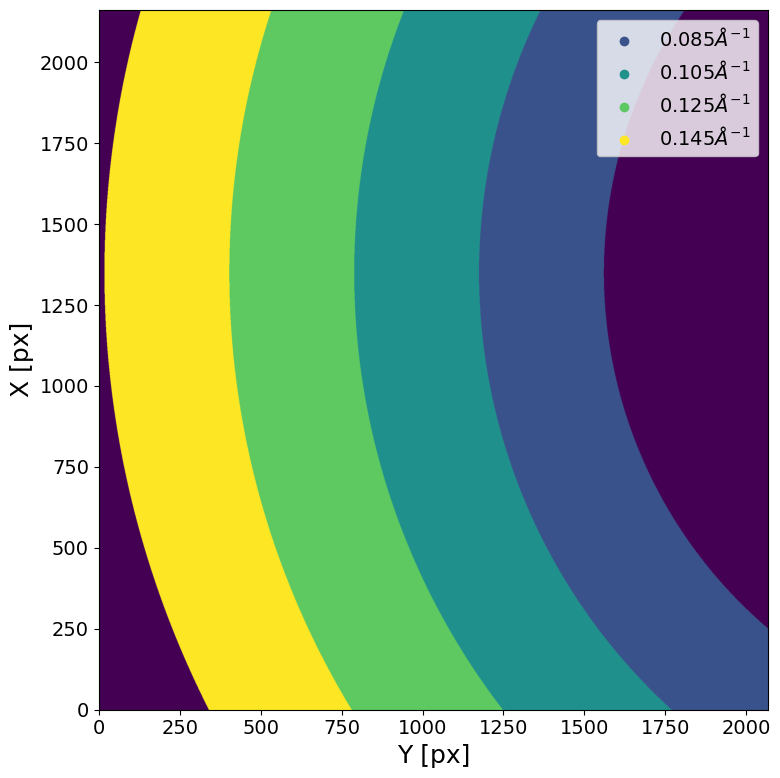

In [13]:
###################
Qs_section = [.085, .105, .125, .145,]
dQ_section = .01
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  222445 pixels (of 4471016 => 4.98 %)
# of pixels below Ith_low treshold ->  941892 pixels (of 4471016 => 21.07 %)
################################################################################



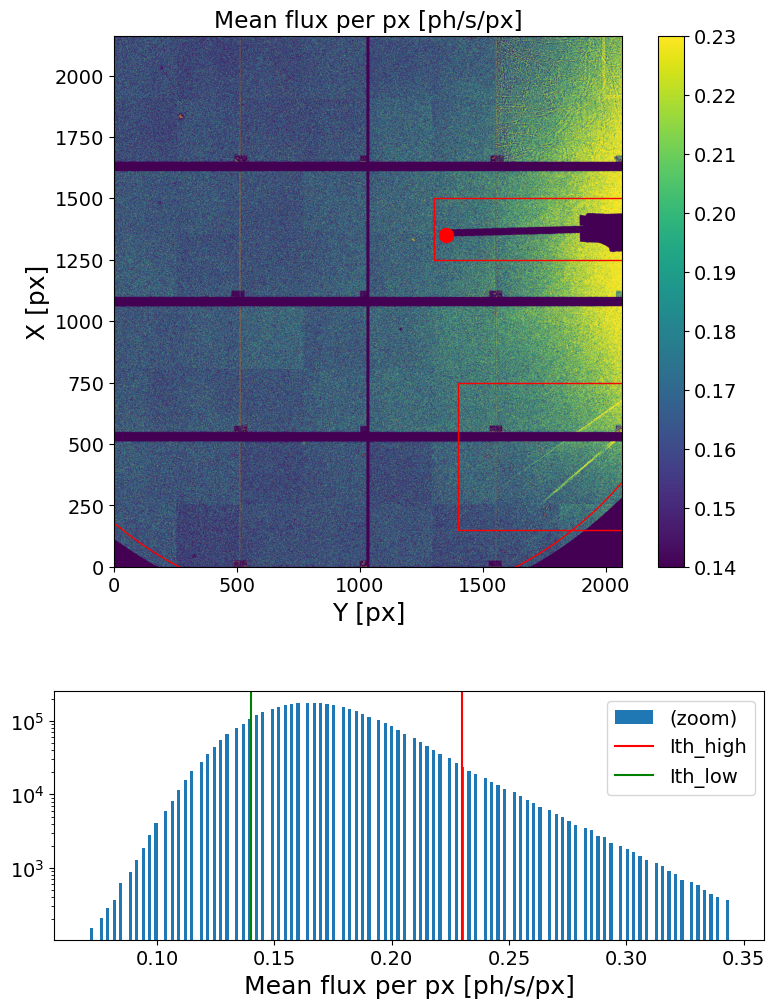

#################################################
Masked area =  85.1810863571054 %
#################################################



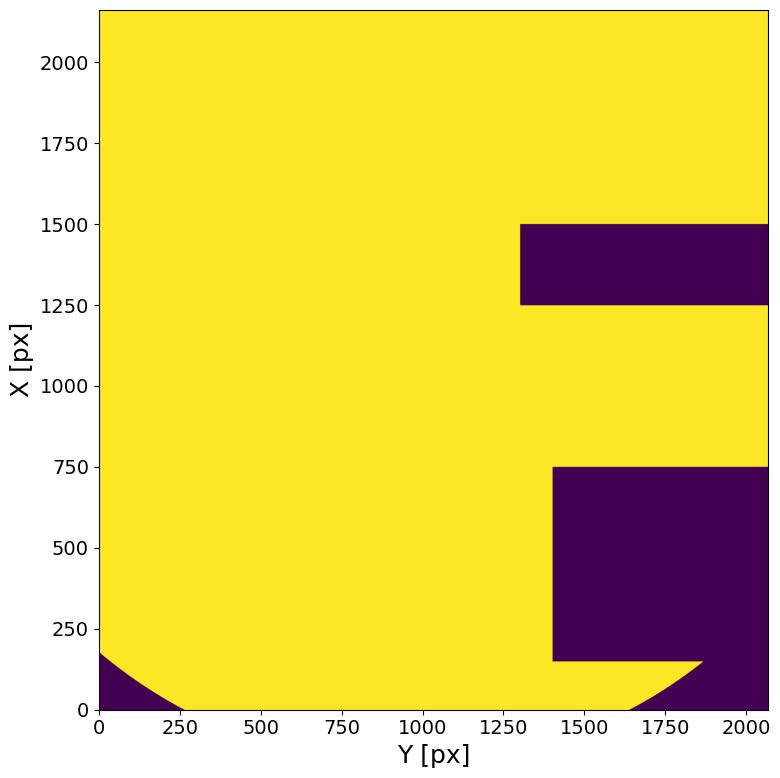

In [14]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':150, 'y0':1400, 'xl':600, 'yl':2000, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .14, Ith_high=.23, Nff=300000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [15]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

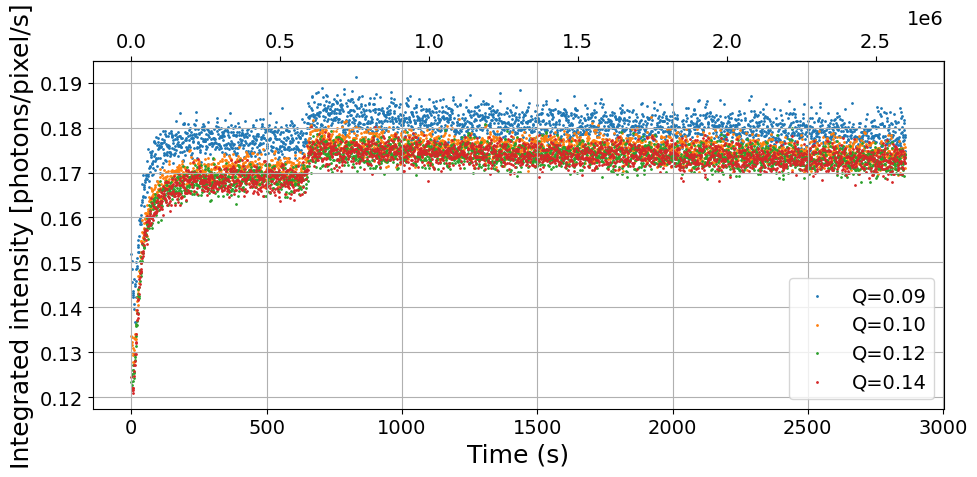

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [17]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.145:   0%|          | 0/4 [00:00<?, ?it/s]

Nff set to 2597152 => (Nff-Nfi) = 128*2^sparse_depth, thrown frames = 2848 (0.14%)
Loading frames ...
Done! (elapsed time = 18.75 s)
Masking data ...
Done! (elapsed time = 51.06 s)
	 | 2097152 frames X 312913 pixels
	 | sparsity = 1.98e-04
	 | memory usage (sparse.csr_array @ float32) = 1.471 GB
Computing sparse multitau G2t...


100%|██████████| 128/128 [02:34<00:00,  1.21s/it]


Done! (elapsed time = 154.81 s)
Computing dense multitau G2t...
	-> computing channels on 1024 frames ...
	-> computing channels on 512 frames ...
	-> computing channels on 256 frames ...
	-> computing channels on 128 frames ...
	-> computing channels on 64 frames ...
	-> computing channels on 32 frames ...
Done! (elapsed time = 10.31 s)


Calculating G2tmt @ q=0.145:  25%|██▌       | 1/4 [03:55<11:45, 235.11s/it]

...

Calculating G2tmt @ q=0.145:  75%|███████▌  | 3/4 [13:22<04:33, 273.88s/it]

Nff set to 2597152 => (Nff-Nfi) = 128*2^sparse_depth, thrown frames = 2848 (0.14%)
Loading frames ...
Done! (elapsed time = 26.74 s)
Masking data ...
Done! (elapsed time = 65.25 s)
	 | 2097152 frames X 547875 pixels
	 | sparsity = 1.91e-04
	 | memory usage (sparse.csr_array @ float32) = 2.467 GB
Computing sparse multitau G2t...


100%|██████████| 128/128 [03:17<00:00,  1.54s/it]


Done! (elapsed time = 197.03 s)
Computing dense multitau G2t...
	-> computing channels on 1024 frames ...
	-> computing channels on 512 frames ...
	-> computing channels on 256 frames ...
	-> computing channels on 128 frames ...
	-> computing channels on 64 frames ...
	-> computing channels on 32 frames ...
Done! (elapsed time = 16.39 s)


Calculating G2tmt @ q=0.145: 100%|██████████| 4/4 [18:29<00:00, 277.31s/it]


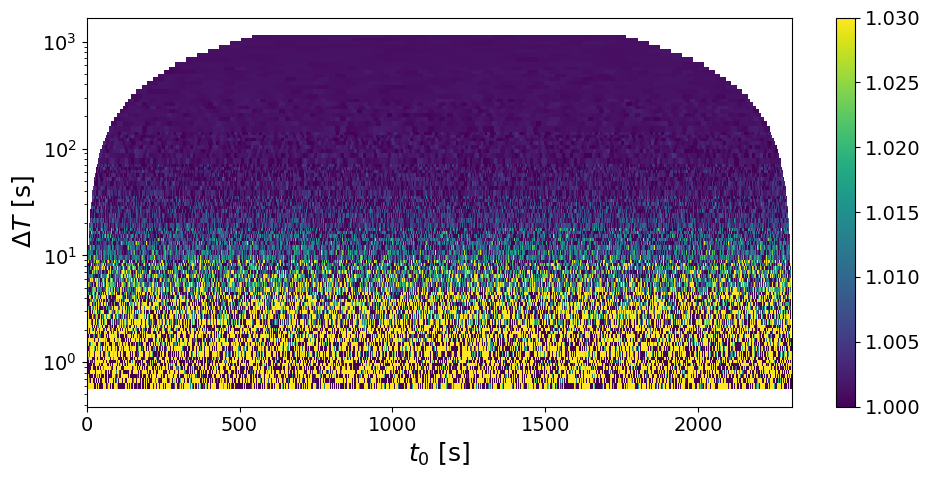

In [18]:
############################
q = .105
vmin, vmax = 1.0, 1.03
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.085,0.01,5.850338,0.229206,3.917825,0.665927,0.015707,2.358624,0.034244,0.000708,2.068637,1.001712,0.000013,0.001301,3.413257
1,0.105,0.01,5.669505,0.129805,2.289530,0.719749,0.011141,1.547848,0.033051,0.000421,1.272669,1.001303,0.000009,0.000893,2.155752
2,0.125,0.01,5.240434,0.114984,2.194174,0.709508,0.010327,1.455448,0.033244,0.000402,1.210645,1.001158,0.000008,0.000801,1.829707
3,0.145,0.01,5.128646,0.111757,2.179070,0.719785,0.010622,1.475676,0.032517,0.000394,1.212183,1.001225,0.000008,0.000776,1.697358


Using Global variables: sample_name, Ndataset, Nscan 



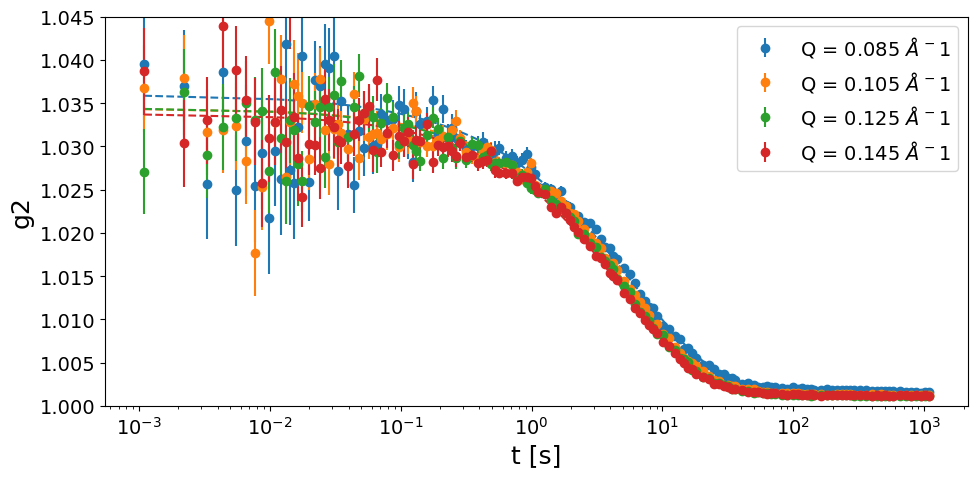

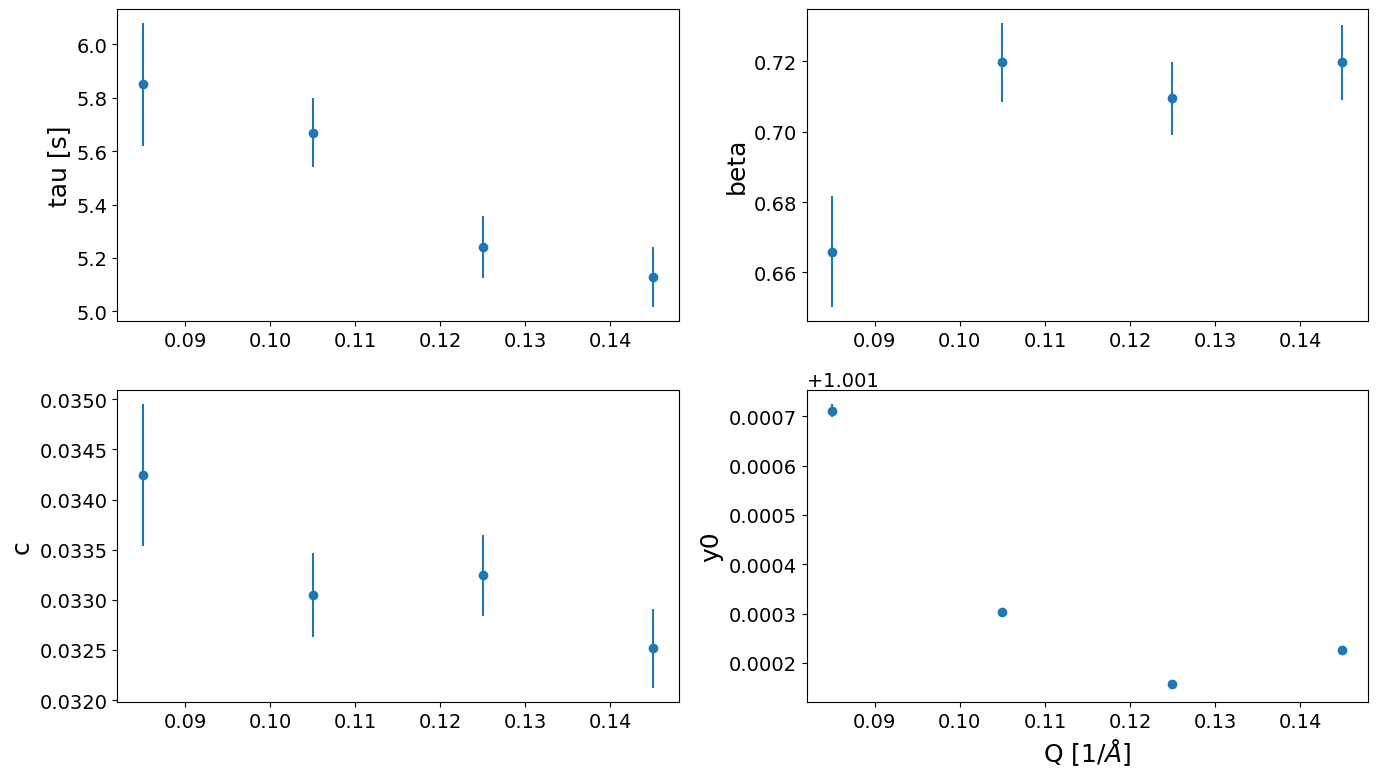

In [19]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.045)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

## XPCS scan: delcoup=3, T=30 60min @ 1ms (GeO2_6q_delcoup3, dataset 1, scan 2)

In [20]:
#######################################
sample_name = 'GeO2_6q_delcoup_3'
Ndataset = 1
Nscan = 2
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 9.699998837562536
itime = 0.0011
theta = 3.0000000000000004
Q = 0.26
T = 65.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h

### Qmask

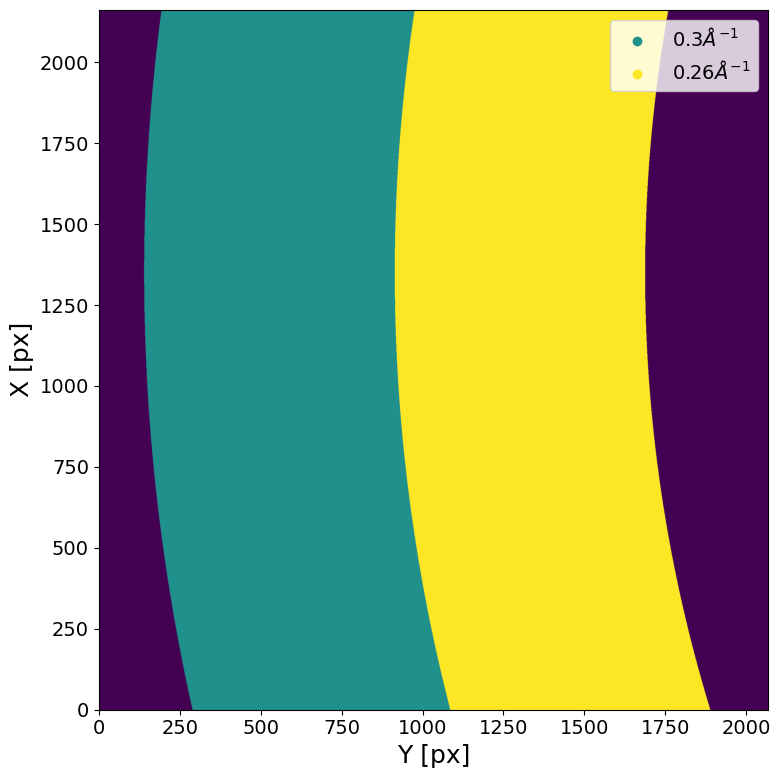

In [21]:
###################
Qs_section = [.3,.26]
dQ_section = .02
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  63479 pixels (of 4471016 => 1.42 %)
# of pixels below Ith_low treshold ->  377852 pixels (of 4471016 => 8.45 %)
################################################################################



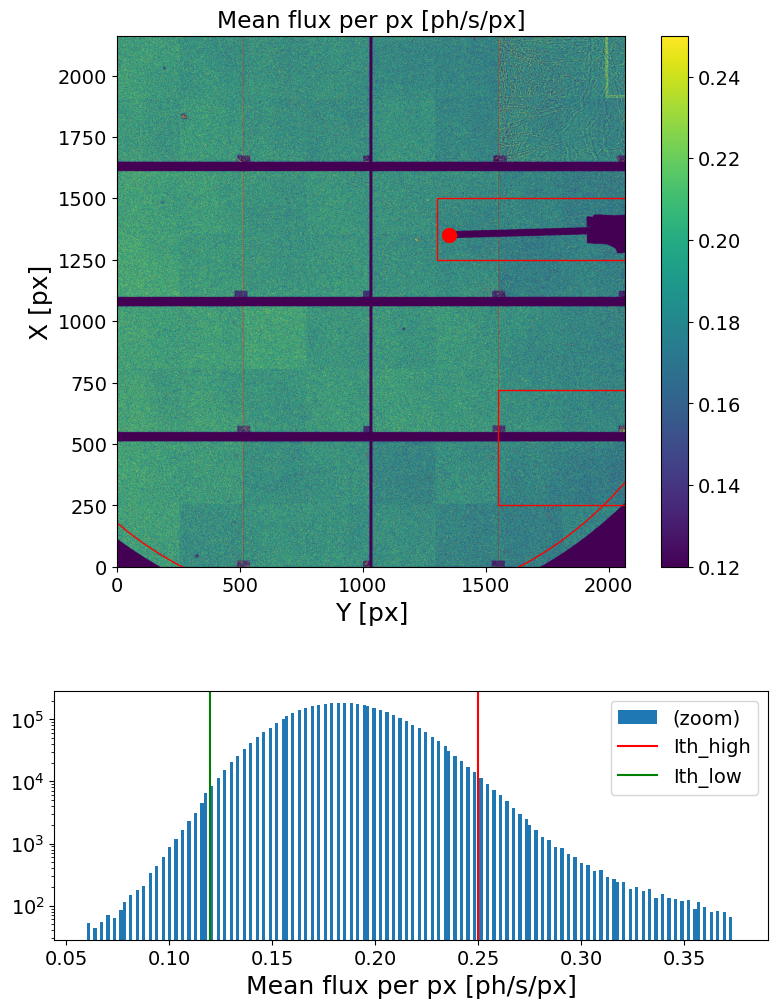

#################################################
Masked area =  88.38167879515528 %
#################################################



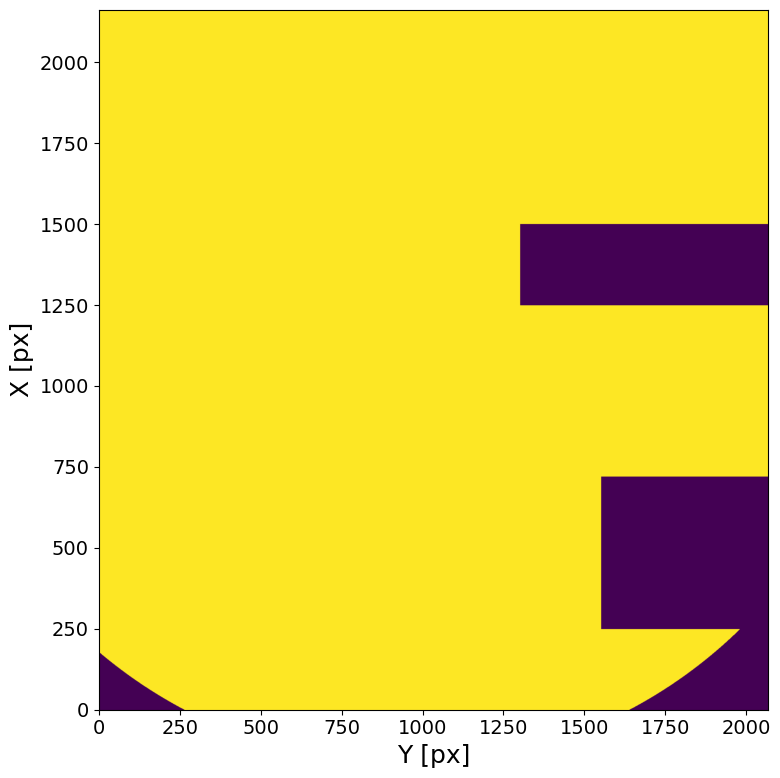

In [22]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':250, 'y0':1550, 'xl':470, 'yl':2000, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .12, Ith_high=.25, Nff=300000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [23]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

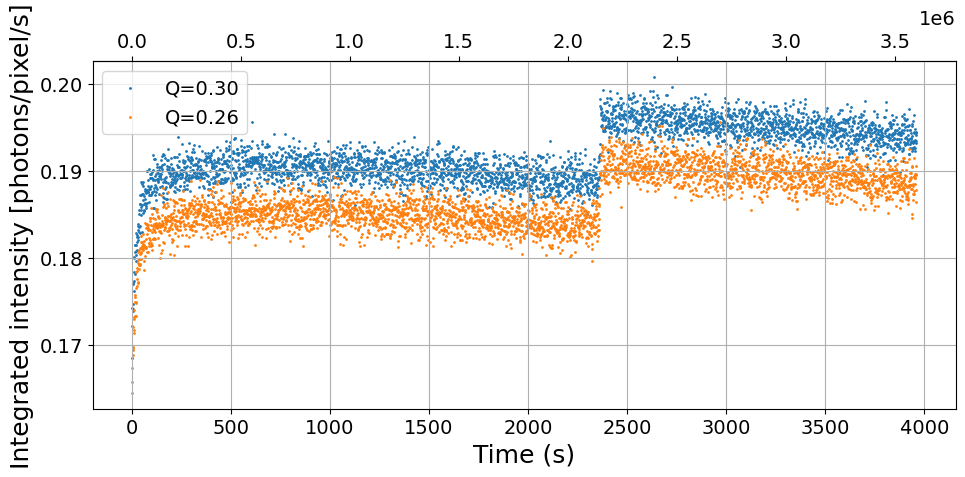

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [25]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.26:   0%|          | 0/2 [00:00<?, ?it/s]

Nff set to 3596576 => (Nff-Nfi) = 189*2^sparse_depth, thrown frames = 3088 (0.1%)
Loading frames ...
Done! (elapsed time = 60.9 s)
Masking data ...
Done! (elapsed time = 140.01 s)
	 | 3096576 frames X 1096545 pixels
	 | sparsity = 2.12e-04
	 | memory usage (sparse.csr_array @ float32) = 8.053 GB
Computing sparse multitau G2t...


100%|██████████| 189/189 [05:38<00:00,  1.79s/it]


Done! (elapsed time = 338.09 s)
Computing dense multitau G2t...
	-> computing channels on 1512 frames ...
	-> computing channels on 756 frames ...
	-> computing channels on 378 frames ...
	-> computing channels on 189 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...
	-> computing channels on 23 frames ...
Done! (elapsed time = 96.84 s)


Calculating G2tmt @ q=0.26:  50%|█████     | 1/2 [10:36<10:36, 636.55s/it]

Nff set to 3596576 => (Nff-Nfi) = 189*2^sparse_depth, thrown frames = 3088 (0.1%)
Loading frames ...
Done! (elapsed time = 82.97 s)
Masking data ...
Done! (elapsed time = 140.87 s)
	 | 3096576 frames X 896841 pixels
	 | sparsity = 2.06e-04
	 | memory usage (sparse.csr_array @ float32) = 6.409 GB
Computing sparse multitau G2t...


100%|██████████| 189/189 [06:13<00:00,  1.98s/it]


Done! (elapsed time = 374.0 s)
Computing dense multitau G2t...
	-> computing channels on 1512 frames ...
	-> computing channels on 756 frames ...
	-> computing channels on 378 frames ...
	-> computing channels on 189 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...
	-> computing channels on 23 frames ...
Done! (elapsed time = 63.32 s)


Calculating G2tmt @ q=0.26: 100%|██████████| 2/2 [21:38<00:00, 649.11s/it]


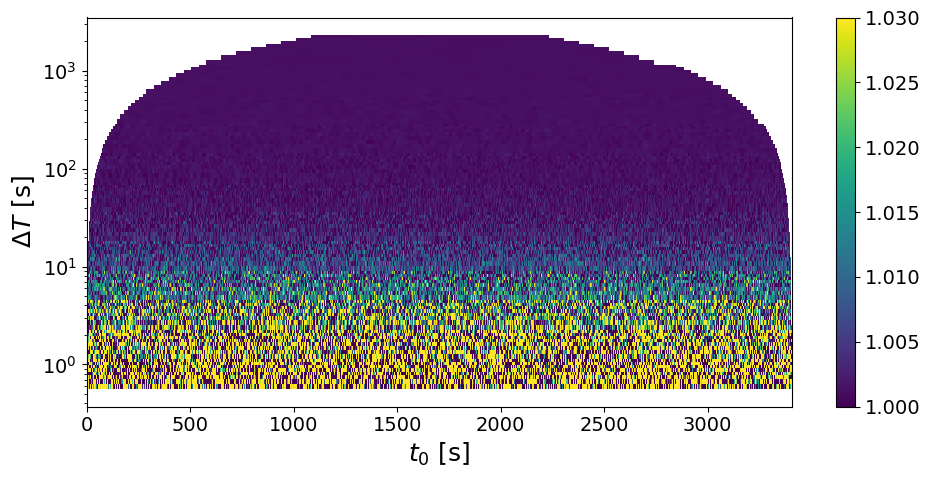

In [26]:
############################
q = .3
vmin, vmax = 1.0, 1.03
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.30,0.02,4.743378,0.067189,1.416474,0.721851,0.006903,0.956337,0.029075,0.000229,0.787785,1.001170,0.000003,0.000329,1.974627
1,0.26,0.02,5.014683,0.068855,1.373077,0.730382,0.006906,0.945539,0.029880,0.000230,0.770257,1.001306,0.000003,0.000349,1.652173


Using Global variables: sample_name, Ndataset, Nscan 



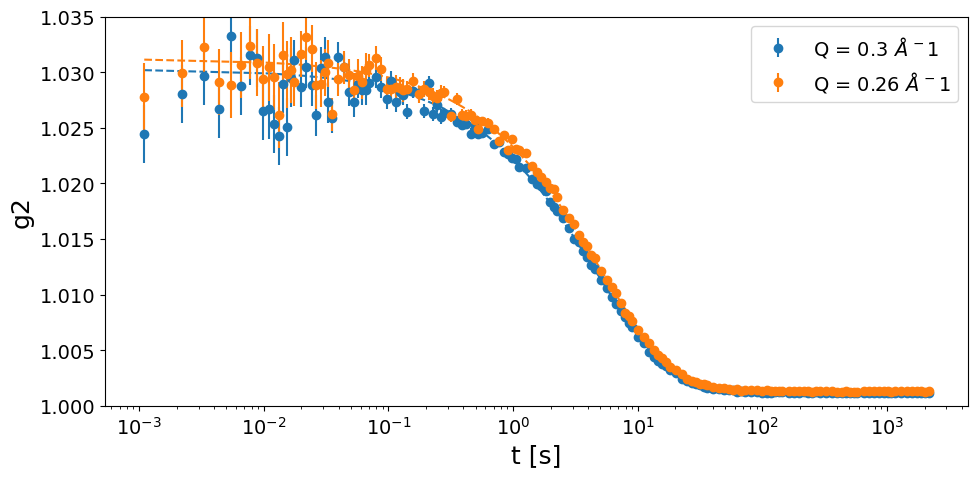

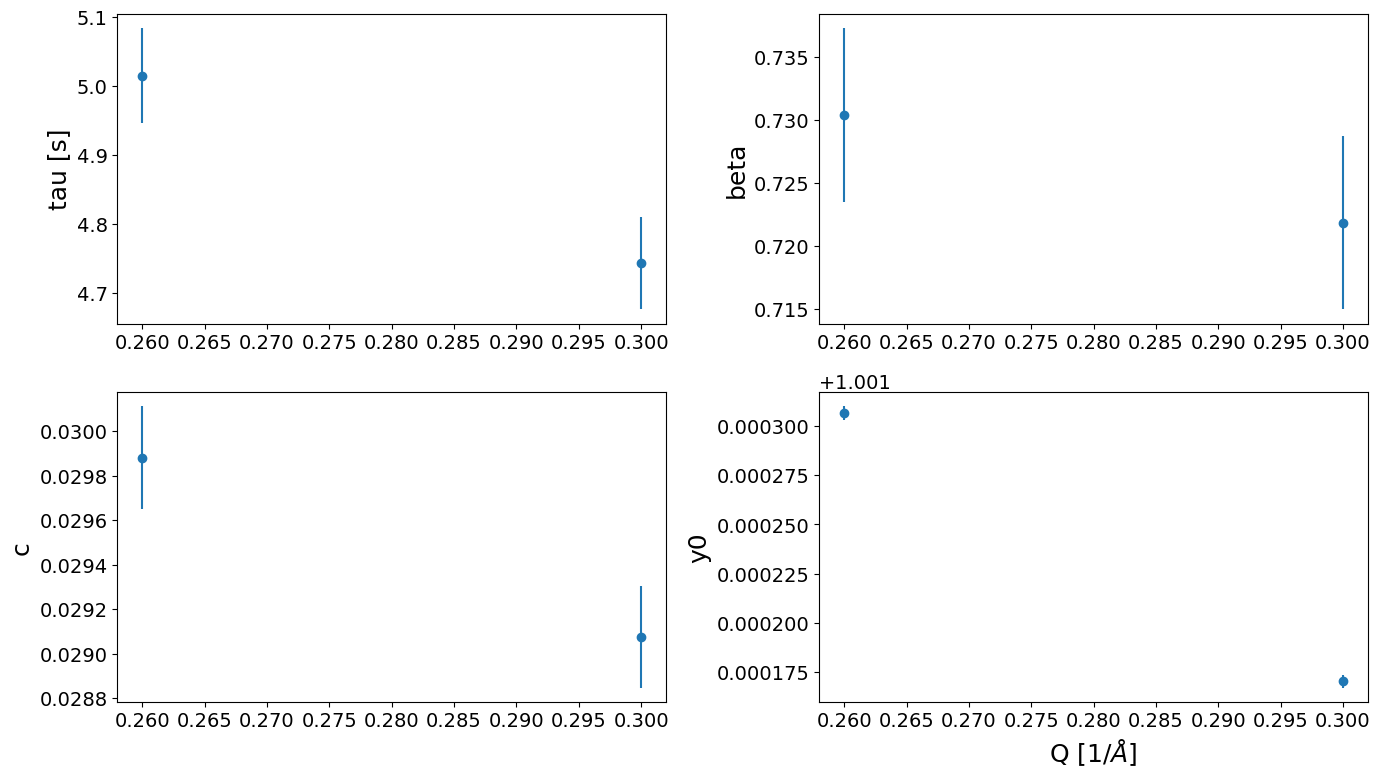

: 

In [ ]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.035)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

##   XPCS scan delcoup=5, T=30, 60min @ 1ms (GeO2_6q_delcoup5, dataset 1, scan 2)

In [4]:
#######################################
sample_name = 'GeO2_6q_delcoup_5'
Ndataset = 1
Nscan = 2
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=60)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 9.699998837562536
itime = 0.0011
theta = 5.0
Q = 0.43
T = 65.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/720 loops)
	 -> loading file	 -> loading file  eiger4m_v2_sparse_frame_0_00012.h5eiger4m_v2_sparse_frame_0_00008.h5  (13/720 loops)(9/720 loops)

	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/720 loops)
	 -> loading file 	 -> loading fileeiger4m_v2_sparse_frame_0_00009.h5 (10/720 loops)
 eiger4m_v2_sparse_frame_0_00001.h5 (2/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00017.h5 (18/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00013.h5 (14/720 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/720 loo

### Qmask

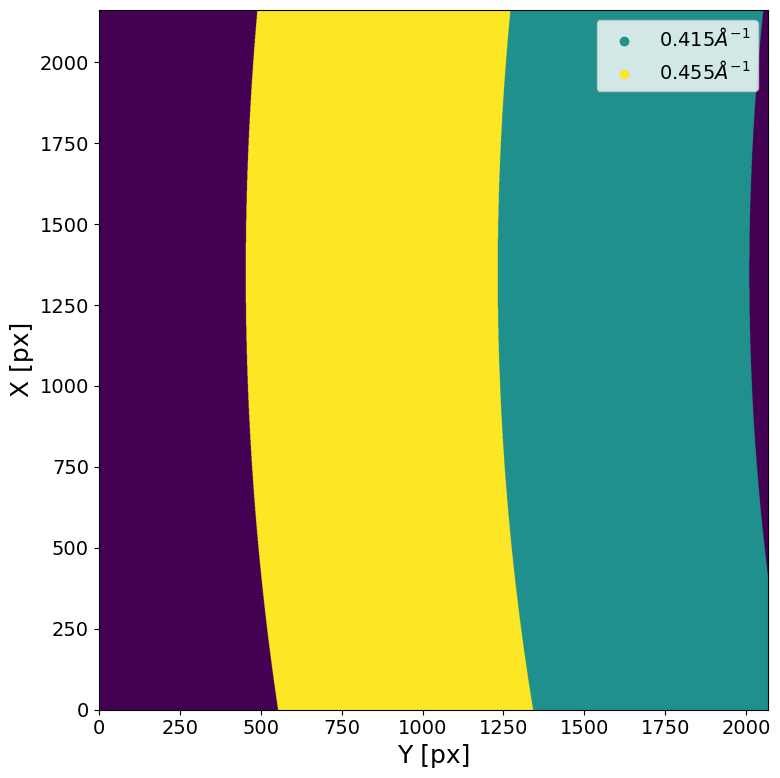

In [5]:
###################
Qs_section = [.415,.455]
dQ_section = .02
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  24341 pixels (of 4471016 => 0.54 %)
# of pixels below Ith_low treshold ->  894734 pixels (of 4471016 => 20.01 %)
################################################################################



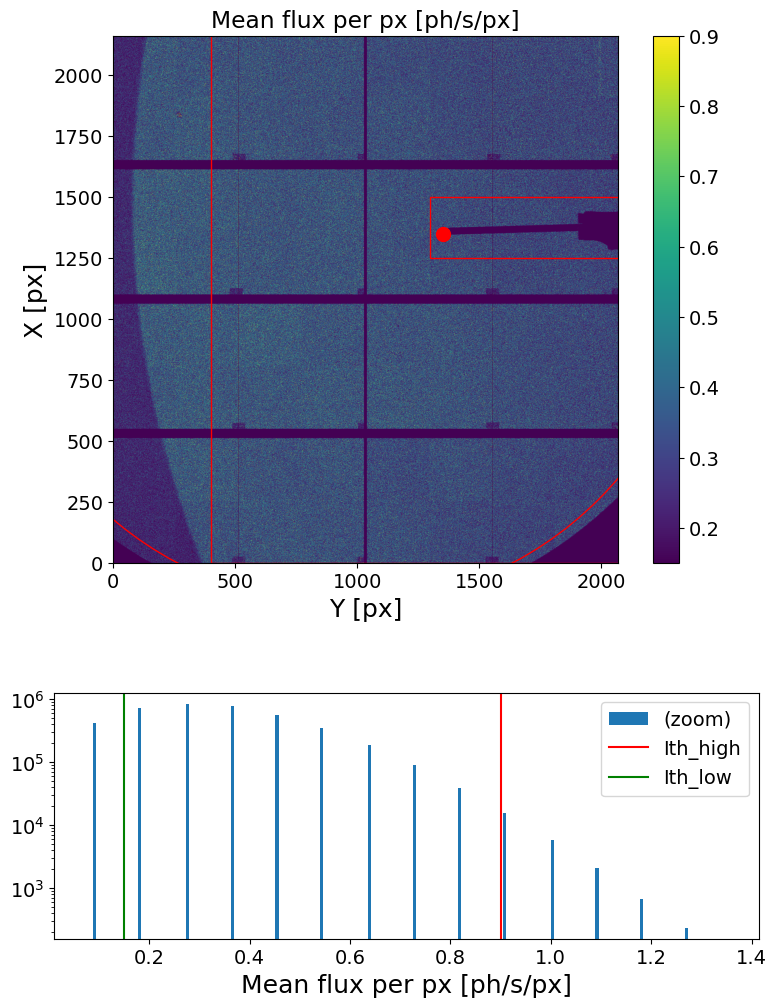

#################################################
Masked area =  74.81720038577362 %
#################################################



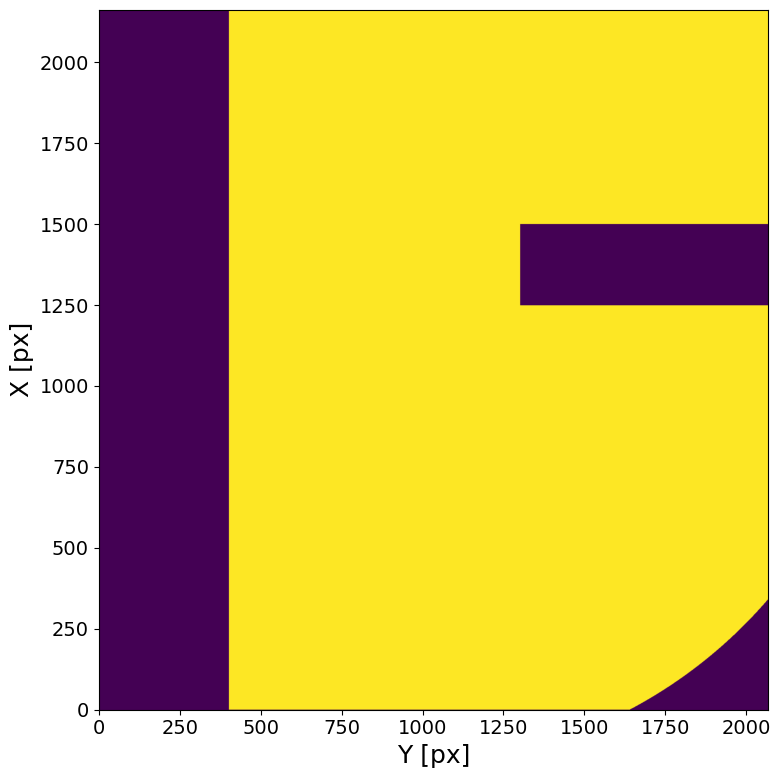

In [6]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':0, 'y0':400, 'xl':3000, 'yl':3000, 'inside':True},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .15, Ith_high=.9, Nff=10000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [7]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

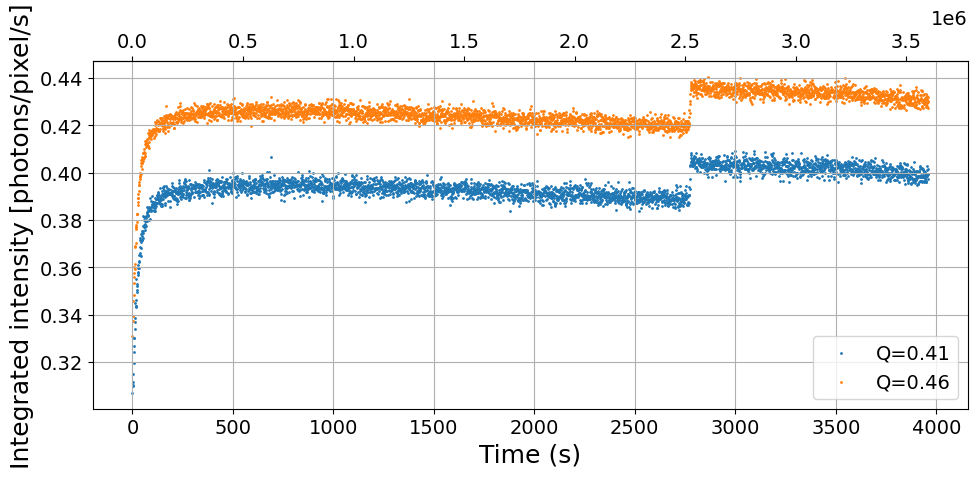

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [10]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.455:   0%|          | 0/2 [00:00<?, ?it/s]

Nff set to 3596576 => (Nff-Nfi) = 189*2^sparse_depth, thrown frames = 3088 (0.1%)
Loading frames ...
Done! (elapsed time = 63.6 s)
Masking data ...
Done! (elapsed time = 110.96 s)
	 | 3096576 frames X 826311 pixels
	 | sparsity = 4.35e-04
	 | memory usage (sparse.csr_array @ float32) = 12.466 GB
Computing sparse multitau G2t...


100%|██████████| 189/189 [05:33<00:00,  1.77s/it]


Done! (elapsed time = 333.82 s)
Computing dense multitau G2t...
	-> computing channels on 1512 frames ...
	-> computing channels on 756 frames ...
	-> computing channels on 378 frames ...
	-> computing channels on 189 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...
	-> computing channels on 23 frames ...
Done! (elapsed time = 39.04 s)


Calculating G2tmt @ q=0.455:  50%|█████     | 1/2 [09:07<09:07, 547.74s/it]

Nff set to 3596576 => (Nff-Nfi) = 189*2^sparse_depth, thrown frames = 3088 (0.1%)
Loading frames ...
Done! (elapsed time = 62.21 s)
Masking data ...
Done! (elapsed time = 154.26 s)
	 | 3096576 frames X 1084848 pixels
	 | sparsity = 4.70e-04
	 | memory usage (sparse.csr_array @ float32) = 17.655 GB
Computing sparse multitau G2t...


100%|██████████| 189/189 [06:30<00:00,  2.06s/it]


Done! (elapsed time = 390.23 s)
Computing dense multitau G2t...
	-> computing channels on 1512 frames ...
	-> computing channels on 756 frames ...
	-> computing channels on 378 frames ...
	-> computing channels on 189 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...
	-> computing channels on 23 frames ...
Done! (elapsed time = 50.55 s)


Calculating G2tmt @ q=0.455: 100%|██████████| 2/2 [20:05<00:00, 602.65s/it]


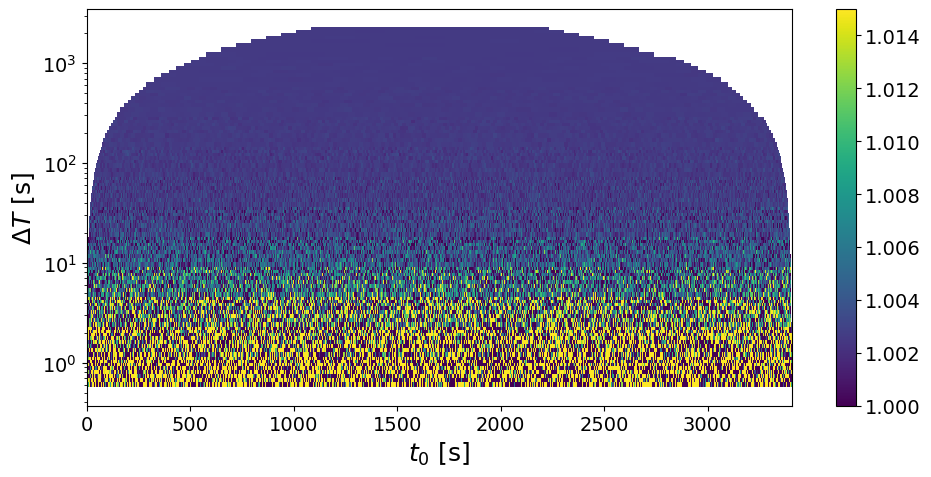

In [11]:
############################
q = 0.415
vmin, vmax = 1.0, 1.015
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.415,0.02,4.841424,0.109664,2.265123,0.723667,0.011158,1.541825,0.007479,0.000094,1.262406,1.002547,0.000001,0.000135,1.116295
1,0.455,0.02,4.854781,0.102986,2.121334,0.720230,0.010356,1.437848,0.006911,0.000081,1.178508,1.001884,0.000001,0.000113,1.267339


Using Global variables: sample_name, Ndataset, Nscan 



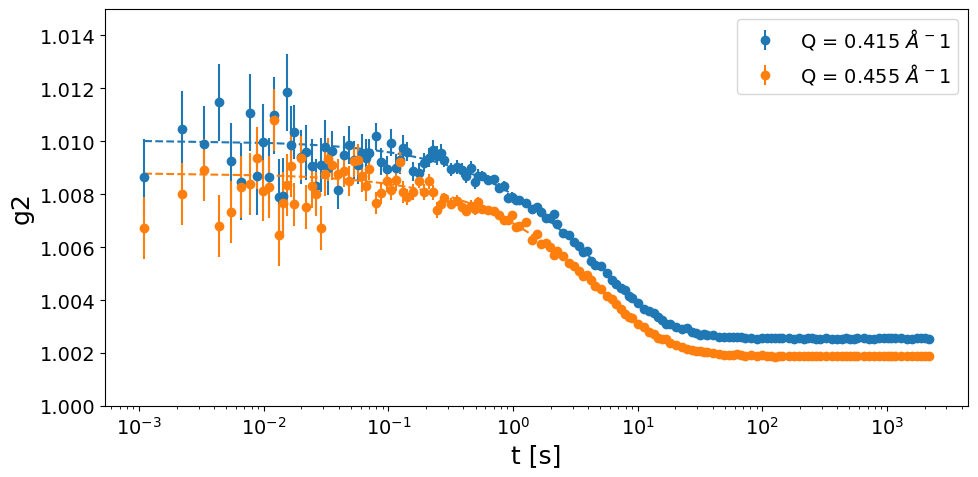

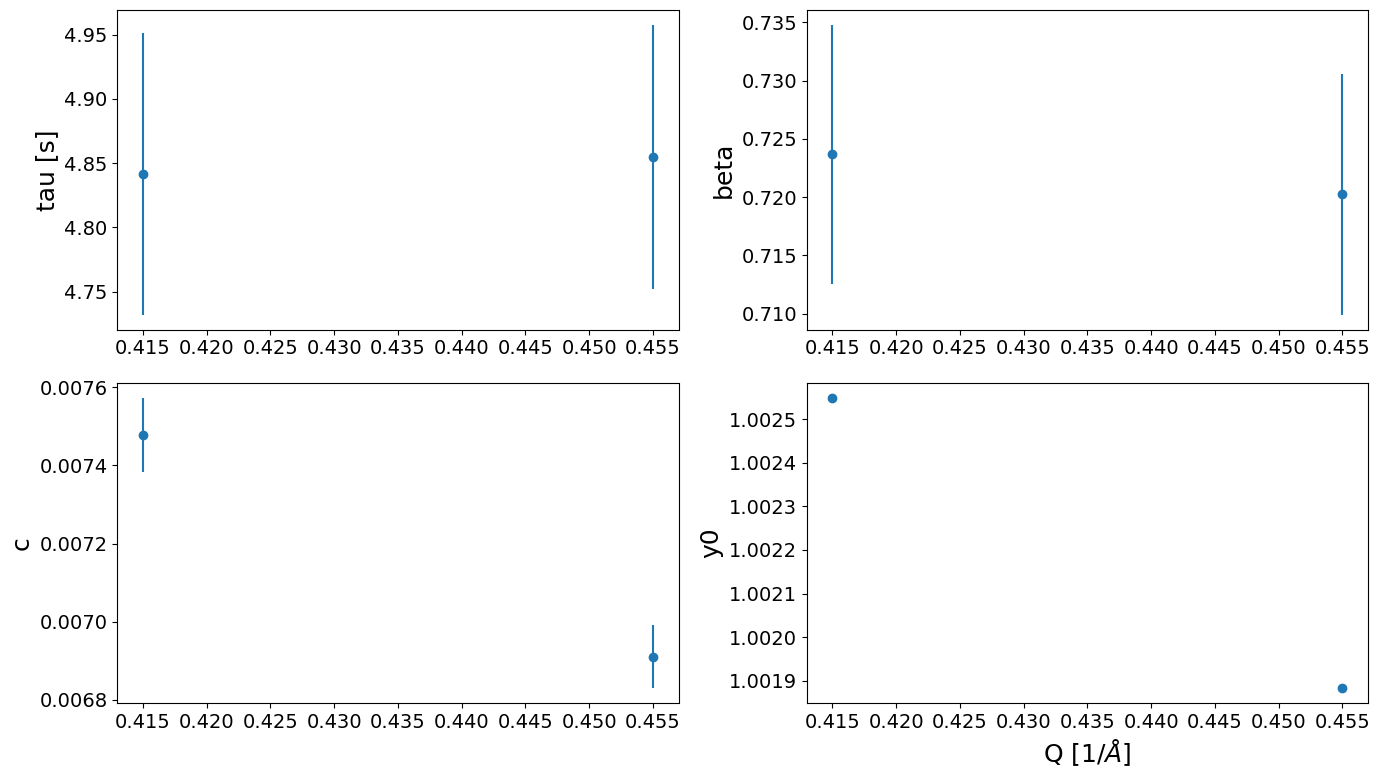

In [12]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.015)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()